In [78]:
import numpy as np
import matplotlib.pyplot as plt

"""
Self-contained module: all auxiliary functions (wavelengths r and b),
the v2-isolated splits, and the contraction maps H_1, H_2, H_3.

Only dependency: numpy. No local module imports -- everything is in this file,
using the same function bodies translated previously.

Input convention (same as before):
    array = [t, u, v]
    t   = array[0]          (scalar)
    u_1 = array[1][0]
    u_2 = array[1][1]
    v_1 = array[2][0]
    v_2 = array[2][1]

Vector-valued maps return numpy arrays of shape (2,).
The H maps take two such arrays: I_r = [t_r, u_r, v_r], I_b = [t_b, u_b, v_b].
"""
# ---------------------------------------------------------------------------
# Parameters -- set these to your problem's values
# ---------------------------------------------------------------------------
# n_r = 1.5143      # refractive index for wavelength r, must satisfy n_r > 1
# n_b = 1.5224      # refractive index for wavelength b, must satisfy n_b > 1
# rho_0 = 1    # rho_0 > 0
# d_0 = 2*10**(5)      # d_0 > 0
# k_0 = rho_0 / d_0
# w = np.array([0.0, 1.0])   # fixed vector w = (0, 1)
n_r = 1.1400     # refractive index for wavelength r, must satisfy n_r > 1
n_b = 1.8660      # refractive index for wavelength b, must satisfy n_b > 1
rho_0 = 2    # rho_0 > 0
d_0 = 4    # d_0 > 0
k_0 = rho_0 / d_0
w = np.array([0.0, 1.0])   # fixed vector w = (0, 1)

def _unpack(array):
    """Split the input array into t, u_1, u_2, v_1, v_2."""
    t = array[0]
    u_1 = array[1][0]
    u_2 = array[1][1]
    v_1 = array[2][0]
    v_2 = array[2][1]
    return t, u_1, u_2, v_1, v_2


# ===========================================================================
# ===========================================================================
#                       WAVELENGTH r FUNCTIONS
# ===========================================================================
# ===========================================================================

def alpha(array):
    """alpha(u) = (u_1 - sqrt((u_1^2+u_2^2)(n_r^2-1) + u_1^2)) / (u_1^2+u_2^2)."""
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    norm_sq = u_1**2 + u_2**2
    root = np.sqrt(norm_sq * (n_r**2 - 1) + u_1**2)
    return (u_1 - root) / norm_sq


def M_r(array):
    """
    M_r(t,u) = (1/n_r) [ (sin t, cos t)
                         - alpha(u) (u_1 sin t - u_2 cos t,
                                     u_1 cos t + u_2 sin t) ].
    """
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    a = alpha(array)
    vec1 = np.array([np.sin(t), np.cos(t)])
    vec2 = np.array([u_1 * np.sin(t) - u_2 * np.cos(t),
                     u_1 * np.cos(t) + u_2 * np.sin(t)])
    return (vec1 - a * vec2) / n_r


def D_r(array):
    """D_r(t,u) = ((n_r-1) d_0 - u_1 (1 - cos t)) / (n_r - w . M_r(t,u))."""
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    Mr = M_r(array)
    numerator = (n_r - 1) * d_0 - u_1 * (1 - np.cos(t))
    denominator = n_r - np.dot(w, Mr)
    return numerator / denominator


def F_r(array):
    """F_r(t,u) = u_1 (sin t, cos t) + D_r(t,u) M_r(t,u)."""
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    return u_1 * np.array([np.sin(t), np.cos(t)]) + D_r(array) * M_r(array)


def Lambda_2r(array):
    """Lambda_{2,r}(t,u) = sqrt(1 + 1/n_r^2 - (2/n_r) w . M_r(t,u))."""
    Mr = M_r(array)
    return np.sqrt(1.0 + 1.0 / n_r**2 - (2.0 / n_r) * np.dot(w, Mr))


def alpha_tilde(array):
    """
    alpha_tilde(u,v) = (n_r^2-1) *
        ( v_1 + ((u_1 v_1 + u_2 v_2)(n_r^2-1) + u_1 v_1) / R ) * (1/(u_1 + R))^2,
    with R = sqrt((u_1^2+u_2^2)(n_r^2-1) + u_1^2).
    """
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    root = np.sqrt((u_1**2 + u_2**2) * (n_r**2 - 1) + u_1**2)
    middle = v_1 + ((u_1 * v_1 + u_2 * v_2) * (n_r**2 - 1) + u_1 * v_1) / root
    return (n_r**2 - 1) * middle * (1.0 / (u_1 + root))**2


def M_r_tilde(array):
    """
    M_r_tilde(t,u,v) = (1/n_r) [ (cos t, -sin t)
        - alpha_tilde(u,v) (u_1 sin t - u_2 cos t,  u_2 sin t + u_1 cos t)
        - alpha(u) ((u_1 - v_2) cos t + (u_2 + v_1) sin t,
                    (v_2 - u_1) sin t + (v_1 + u_2) cos t) ].
    """
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    a = alpha(array)
    a_t = alpha_tilde(array)
    vec1 = np.array([np.cos(t), -np.sin(t)])
    vec2 = np.array([u_1 * np.sin(t) - u_2 * np.cos(t),
                     u_2 * np.sin(t) + u_1 * np.cos(t)])
    vec3 = np.array([(u_1 - v_2) * np.cos(t) + (u_2 + v_1) * np.sin(t),
                     (v_2 - u_1) * np.sin(t) + (v_1 + u_2) * np.cos(t)])
    return (vec1 - a_t * vec2 - a * vec3) / n_r


def D_r_tilde(array):
    """
    D_r_tilde(t,u,v) =
        [ (v_1 (cos t - 1) - u_1 sin t)(n_r - w . M_r)
          + ((n_r-1) d_0 - u_1 (1 - cos t)) (w . M_r_tilde) ]
        / (n_r - w . M_r)^2.
    """
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    w_dot_Mr = np.dot(w, M_r(array))
    w_dot_Mr_t = np.dot(w, M_r_tilde(array))
    numerator = ((v_1 * (np.cos(t) - 1) - u_1 * np.sin(t)) * (n_r - w_dot_Mr)
                 + ((n_r - 1) * d_0 - u_1 * (1 - np.cos(t))) * w_dot_Mr_t)
    return numerator / (n_r - w_dot_Mr)**2


def F_r_tilde(array):
    """
    F_r_tilde(t,u,v) = u_1 (cos t, -sin t) + v_1 (sin t, cos t)
                       + M_r_tilde(t,u,v) D_r(t,u) + M_r(t,u) D_r_tilde(t,u,v).
    """
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    term1 = u_1 * np.array([np.cos(t), -np.sin(t)])
    term2 = v_1 * np.array([np.sin(t), np.cos(t)])
    return term1 + term2 + M_r_tilde(array) * D_r(array) + M_r(array) * D_r_tilde(array)


def Lambda_2r_tilde(array):
    """Lambda_2r_tilde(t,u,v) = -(1/n_r) (w . M_r_tilde) / Lambda_2r(t,u)."""
    return -(1.0 / n_r) * np.dot(w, M_r_tilde(array)) / Lambda_2r(array)


# ===========================================================================
# ===========================================================================
#                       WAVELENGTH b FUNCTIONS
# ===========================================================================
# ===========================================================================

def alpha_b(array):
    """alpha_b(u) = (u_1 - sqrt((u_1^2+u_2^2)(n_b^2-1) + u_1^2)) / (u_1^2+u_2^2)."""
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    norm_sq = u_1**2 + u_2**2
    root = np.sqrt(norm_sq * (n_b**2 - 1) + u_1**2)
    return (u_1 - root) / norm_sq


def M_b(array):
    """
    M_b(t,u) = (1/n_b) [ (sin t, cos t)
                         - alpha_b(u) (u_1 sin t - u_2 cos t,
                                       u_1 cos t + u_2 sin t) ].
    """
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    a = alpha_b(array)
    vec1 = np.array([np.sin(t), np.cos(t)])
    vec2 = np.array([u_1 * np.sin(t) - u_2 * np.cos(t),
                     u_1 * np.cos(t) + u_2 * np.sin(t)])
    return (vec1 - a * vec2) / n_b


def D_b(array):
    """D_b(t,u) = ((n_b-1) d_0 - u_1 (1 - cos t)) / (n_b - w . M_b(t,u))."""
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    Mb = M_b(array)
    numerator = (n_b - 1) * d_0 - u_1 * (1 - np.cos(t))
    denominator = n_b - np.dot(w, Mb)
    return numerator / denominator


def F_b(array):
    """F_b(t,u) = u_1 (sin t, cos t) + D_b(t,u) M_b(t,u)."""
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    return u_1 * np.array([np.sin(t), np.cos(t)]) + D_b(array) * M_b(array)


def Lambda_2b(array):
    """Lambda_{2,b}(t,u) = sqrt(1 + 1/n_b^2 - (2/n_b) w . M_b(t,u))."""
    Mb = M_b(array)
    return np.sqrt(1.0 + 1.0 / n_b**2 - (2.0 / n_b) * np.dot(w, Mb))


def alpha_tilde_b(array):
    """
    alpha_tilde_b(u,v) = (n_b^2-1) *
        ( v_1 + ((u_1 v_1 + u_2 v_2)(n_b^2-1) + u_1 v_1) / R ) * (1/(u_1 + R))^2,
    with R = sqrt((u_1^2+u_2^2)(n_b^2-1) + u_1^2).
    """
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    root = np.sqrt((u_1**2 + u_2**2) * (n_b**2 - 1) + u_1**2)
    middle = v_1 + ((u_1 * v_1 + u_2 * v_2) * (n_b**2 - 1) + u_1 * v_1) / root
    return (n_b**2 - 1) * middle * (1.0 / (u_1 + root))**2


def M_b_tilde(array):
    """
    M_b_tilde(t,u,v) = (1/n_b) [ (cos t, -sin t)
        - alpha_tilde_b(u,v) (u_1 sin t - u_2 cos t,  u_2 sin t + u_1 cos t)
        - alpha_b(u) ((u_1 - v_2) cos t + (u_2 + v_1) sin t,
                      (v_2 - u_1) sin t + (v_1 + u_2) cos t) ].
    """
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    a = alpha_b(array)
    a_t = alpha_tilde_b(array)
    vec1 = np.array([np.cos(t), -np.sin(t)])
    vec2 = np.array([u_1 * np.sin(t) - u_2 * np.cos(t),
                     u_2 * np.sin(t) + u_1 * np.cos(t)])
    vec3 = np.array([(u_1 - v_2) * np.cos(t) + (u_2 + v_1) * np.sin(t),
                     (v_2 - u_1) * np.sin(t) + (v_1 + u_2) * np.cos(t)])
    return (vec1 - a_t * vec2 - a * vec3) / n_b


def D_b_tilde(array):
    """
    D_b_tilde(t,u,v) =
        [ (v_1 (cos t - 1) - u_1 sin t)(n_b - w . M_b)
          + ((n_b-1) d_0 - u_1 (1 - cos t)) (w . M_b_tilde) ]
        / (n_b - w . M_b)^2.
    """
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    w_dot_Mb = np.dot(w, M_b(array))
    w_dot_Mb_t = np.dot(w, M_b_tilde(array))
    numerator = ((v_1 * (np.cos(t) - 1) - u_1 * np.sin(t)) * (n_b - w_dot_Mb)
                 + ((n_b - 1) * d_0 - u_1 * (1 - np.cos(t))) * w_dot_Mb_t)
    return numerator / (n_b - w_dot_Mb)**2


def F_b_tilde(array):
    """
    F_b_tilde(t,u,v) = u_1 (cos t, -sin t) + v_1 (sin t, cos t)
                       + M_b_tilde(t,u,v) D_b(t,u) + M_b(t,u) D_b_tilde(t,u,v).
    """
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    term1 = u_1 * np.array([np.cos(t), -np.sin(t)])
    term2 = v_1 * np.array([np.sin(t), np.cos(t)])
    return term1 + term2 + M_b_tilde(array) * D_b(array) + M_b(array) * D_b_tilde(array)


def Lambda_2b_tilde(array):
    """Lambda_2b_tilde(t,u,v) = -(1/n_b) (w . M_b_tilde) / Lambda_2b(t,u)."""
    return -(1.0 / n_b) * np.dot(w, M_b_tilde(array)) / Lambda_2b(array)


# ===========================================================================
# ===========================================================================
#         v2-ISOLATED SPLITS (wavelength r):
#         f_tilde(t,u,v) = v_2 * f_tilde_v2 + f_tilde_others
# ===========================================================================
# ===========================================================================

def alpha_tilde_v2(array):
    """
    Coefficient of v_2 in alpha_tilde:
    alpha_tilde_v2(u) = (n_r^2-1) * (u_2 (n_r^2-1) / R) * (1/(u_1+R))^2.
    """
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    R = np.sqrt((u_1**2 + u_2**2) * (n_r**2 - 1) + u_1**2)
    return (n_r**2 - 1) * (u_2 * (n_r**2 - 1) / R) * (1.0 / (u_1 + R))**2


def alpha_tilde_others(array):
    """
    v_2-free part of alpha_tilde (= alpha_tilde with v_2 set to 0):
    (n_r^2-1) * ( v_1 + (u_1 v_1 (n_r^2-1) + u_1 v_1)/R ) * (1/(u_1+R))^2.
    """
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    R = np.sqrt((u_1**2 + u_2**2) * (n_r**2 - 1) + u_1**2)
    middle = v_1 + (u_1 * v_1 * (n_r**2 - 1) + u_1 * v_1) / R
    return (n_r**2 - 1) * middle * (1.0 / (u_1 + R))**2


def M_r_tilde_v2(array):
    """
    M_r_tilde_v2(t,u,v) = (1/n_r) [ - alpha_tilde_v2(u) (u_1 sin t - u_2 cos t,
                                                         u_2 sin t + u_1 cos t)
                                    - alpha(u) (-cos t, sin t) ].
    """
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    a = alpha(array)
    a_v2 = alpha_tilde_v2(array)
    vec2 = np.array([u_1 * np.sin(t) - u_2 * np.cos(t),
                     u_2 * np.sin(t) + u_1 * np.cos(t)])
    vec3_v2 = np.array([-np.cos(t), np.sin(t)])
    return (-a_v2 * vec2 - a * vec3_v2) / n_r


def M_r_tilde_others(array):
    """
    M_r_tilde_others(t,u,v) = (1/n_r) [ (cos t, -sin t)
        - alpha_tilde_others(u,v) (u_1 sin t - u_2 cos t,  u_2 sin t + u_1 cos t)
        - alpha(u) (u_1 cos t + (u_2+v_1) sin t,  -u_1 sin t + (v_1+u_2) cos t) ].
    """
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    a = alpha(array)
    a_oth = alpha_tilde_others(array)
    vec1 = np.array([np.cos(t), -np.sin(t)])
    vec2 = np.array([u_1 * np.sin(t) - u_2 * np.cos(t),
                     u_2 * np.sin(t) + u_1 * np.cos(t)])
    vec3_oth = np.array([u_1 * np.cos(t) + (u_2 + v_1) * np.sin(t),
                         -u_1 * np.sin(t) + (v_1 + u_2) * np.cos(t)])
    return (vec1 - a_oth * vec2 - a * vec3_oth) / n_r


def D_r_tilde_v2(array):
    """
    D_r_tilde_v2 = ((n_r-1) d_0 - u_1 (1 - cos t)) (w . M_r_tilde_v2)
                   / (n_r - w . M_r)^2.
    """
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    w_dot_Mr = np.dot(w, M_r(array))
    w_dot_Mv2 = np.dot(w, M_r_tilde_v2(array))
    return ((n_r - 1) * d_0 - u_1 * (1 - np.cos(t))) * w_dot_Mv2 / (n_r - w_dot_Mr)**2


def D_r_tilde_others(array):
    """
    D_r_tilde_others = [ (v_1 (cos t - 1) - u_1 sin t)(n_r - w . M_r)
                         + ((n_r-1) d_0 - u_1 (1 - cos t)) (w . M_r_tilde_others) ]
                       / (n_r - w . M_r)^2.
    """
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    w_dot_Mr = np.dot(w, M_r(array))
    w_dot_Moth = np.dot(w, M_r_tilde_others(array))
    numerator = ((v_1 * (np.cos(t) - 1) - u_1 * np.sin(t)) * (n_r - w_dot_Mr)
                 + ((n_r - 1) * d_0 - u_1 * (1 - np.cos(t))) * w_dot_Moth)
    return numerator / (n_r - w_dot_Mr)**2


def F_r_tilde_v2(array):
    """F_r_tilde_v2 = M_r_tilde_v2 * D_r + M_r * D_r_tilde_v2."""
    return M_r_tilde_v2(array) * D_r(array) + M_r(array) * D_r_tilde_v2(array)


def F_r_tilde_others(array):
    """
    F_r_tilde_others = u_1 (cos t, -sin t) + v_1 (sin t, cos t)
                       + M_r_tilde_others * D_r + M_r * D_r_tilde_others.
    """
    t, u_1, u_2, v_1, v_2 = _unpack(array)
    term1 = u_1 * np.array([np.cos(t), -np.sin(t)])
    term2 = v_1 * np.array([np.sin(t), np.cos(t)])
    return (term1 + term2
            + M_r_tilde_others(array) * D_r(array)
            + M_r(array) * D_r_tilde_others(array))


def Lambda_2r_tilde_v2(array):
    """Lambda_2r_tilde_v2 = -(1/n_r) (w . M_r_tilde_v2) / Lambda_2r."""
    return -(1.0 / n_r) * np.dot(w, M_r_tilde_v2(array)) / Lambda_2r(array)


def Lambda_2r_tilde_others(array):
    """Lambda_2r_tilde_others = -(1/n_r) (w . M_r_tilde_others) / Lambda_2r."""
    return -(1.0 / n_r) * np.dot(w, M_r_tilde_others(array)) / Lambda_2r(array)


# ===========================================================================
# ===========================================================================
#               CONTRACTION MAPS H_1, H_2, H_3
#               I_r = [t_r, u_r, v_r],  I_b = [t_b, u_b, v_b]
# ===========================================================================
# ===========================================================================

def H_1(I_r, I_b):
    """H_1(I_r, I_b) = F_r_tilde_1(I_r) / F_b_tilde_1(I_b)."""
    return F_r_tilde(I_r)[0] / F_b_tilde(I_b)[0]


def H_2(I_r, I_b):
    """H_2(I_r, I_b) = u_{r2}  (second component of u_r)."""
    return I_r[1][1]


def H_3(I_r, I_b):
    """
    H_3(I_r, I_b) = the value of v_2 (= z_3'(t)) isolated from

        F_r_tilde_1(I_r) (M_r1(I_r) Lambda_2b_tilde(I_b) - M_b1_tilde(I_b) Lambda_2r(I_r))
      = F_b_tilde_1(I_b) (M_r1_tilde(I_r) Lambda_2b(I_b) - M_b1(I_b) Lambda_2r_tilde(I_r)),

    namely

        [ F_b_tilde_1(I_b) (M_r1_tilde_others(I_r) Lambda_2b(I_b)
                            - M_b1(I_b) Lambda_2r_tilde_others(I_r))
          - F_r_tilde_1_others(I_r) (M_r1(I_r) Lambda_2b_tilde(I_b)
                                     - M_b1_tilde(I_b) Lambda_2r(I_r)) ]
        /
        [ F_r_tilde_1_v2(I_r) (M_r1(I_r) Lambda_2b_tilde(I_b)
                               - M_b1_tilde(I_b) Lambda_2r(I_r))
          - F_b_tilde_1(I_b) (M_r1_tilde_v2(I_r) Lambda_2b(I_b)
                              - M_b1(I_b) Lambda_2r_tilde_v2(I_r)) ].
    """
    # --- pieces evaluated at I_r (wavelength r) ---
    Mr1 = M_r(I_r)[0]                          # M_r1(I_r)
    Lam_r = Lambda_2r(I_r)                     # Lambda_2r(I_r)
    Mr1_oth = M_r_tilde_others(I_r)[0]         # M_r1_tilde_others(I_r)
    Mr1_v2 = M_r_tilde_v2(I_r)[0]              # M_r1_tilde_v2(I_r)
    LamT_r_oth = Lambda_2r_tilde_others(I_r)   # Lambda_2r_tilde_others(I_r)
    LamT_r_v2 = Lambda_2r_tilde_v2(I_r)        # Lambda_2r_tilde_v2(I_r)
    Fr1_oth = F_r_tilde_others(I_r)[0]         # F_r1_tilde_others(I_r)
    Fr1_v2 = F_r_tilde_v2(I_r)[0]              # F_r1_tilde_v2(I_r)

    # --- pieces evaluated at I_b (wavelength b, full functions) ---
    Fb1_t = F_b_tilde(I_b)[0]                  # F_b1_tilde(I_b)
    Mb1 = M_b(I_b)[0]                          # M_b1(I_b)
    Mb1_t = M_b_tilde(I_b)[0]                  # M_b1_tilde(I_b)
    Lam_b = Lambda_2b(I_b)                     # Lambda_2b(I_b)
    LamT_b = Lambda_2b_tilde(I_b)              # Lambda_2b_tilde(I_b)

    # common bracket appearing in numerator and denominator
    bracket = Mr1 * LamT_b - Mb1_t * Lam_r     # M_r1 Lambda_2b_tilde - M_b1_tilde Lambda_2r

    numerator = (Fb1_t * (Mr1_oth * Lam_b - Mb1 * LamT_r_oth)
                 - Fr1_oth * bracket)
    denominator = (Fr1_v2 * bracket
                   - Fb1_t * (Mr1_v2 * Lam_b - Mb1 * LamT_r_v2))
    return numerator / denominator


# ===========================================================================
# Admissible point P  (eq:admissible P)
# ===========================================================================

def Delta_r():
    """Delta_r = n_r / (n_r - 1)."""
    return n_r / (n_r - 1)


def Delta_b():
    """Delta_b = n_b / (n_b - 1)."""
    return n_b / (n_b - 1)


def P(k_0):
    """
    P = ( (Db - Dr + S) / (Dr - Db + S),
          0,
          ((Db + Dr + S) / 2) * rho_0 ),
    where Dr = Delta_r, Db = Delta_b, k_0 = rho_0 / d_0,
    and S = sqrt((Db - Dr)^2 - 4 k_0 Db Dr).
    Returns np.array([P_1, P_2, P_3]).
    """
    Dr = Delta_r()
    Db = Delta_b()
    # k_0 = rho_0 / d_0

    discriminant = (Db - Dr)**2 - 4.0 * k_0 * Db * Dr
    if discriminant < 0:
        raise ValueError(
            f"Negative discriminant ({discriminant:.6e}): "
            "(Delta_b - Delta_r)^2 - 4 k_0 Delta_b Delta_r < 0 for the "
            "current n_r, n_b, rho_0, d_0 -- P is not real."
        )
    S = np.sqrt(discriminant)

    P_1 = (Db - Dr + S) / (Dr - Db + S)
    P_2 = 0.0
    P_3 = ((Db + Dr + S) / 2.0) * rho_0

    return np.array([P_1, P_2, P_3])

In [94]:
from scipy.integrate import quad
from scipy.integrate import quad_vec
from scipy.interpolate import CubicSpline

delta = 0.95/2
k = 15
dinterval = np.linspace(-delta, delta, k)
def findingsolution(k_0, n , tol):
    def g(t):
        return t*P(k_0)
    def dg(t):
        return P(k_0)

    def h_t(t, g, dg):
        f = g(t) 
        df = dg(t)
        h_2 = f[2] #z_2'(t)=z_3(t)

        I_r = [t, [f[1]+rho_0, f[2]], [h_2, 0]]
        I_b = [f[0], [g(f[0])[1]+rho_0, g(f[0])[2]], dg(f[0])[1:]] 
        
        h_3 = H_3(I_r, I_b)

        I_r[2][1] = h_3 # z_3'(t)=H_3(t)

        h_1 = H_1(I_r, I_b)
        return np.array([h_1, h_2, h_3])
    
    def H_t(t):
        return h_t(t, g, dg)

    k = dinterval.size
    Z_array = np.zeros((n, k , 3))
    
    for i in np.arange( n):
        print(f"i={i}")
        if i == 0:
            for j in np.arange(k):
                Z_array[i][j] = g(dinterval[j])
            continue   

        for j in np.arange(k):
            print(f"j={j}")
            Z_array[i][j], err, info = quad_vec(H_t, 0, dinterval[j], full_output= True, limit=n, epsabs = tol, epsrel = tol )
            print("Integral done")
            print(f"Final error reached: {err}")
             
            if not info.success:
                print(f"Convergence failed! Message: {info.message}")
                
                break
            
        if not info.success:
            break
        
        diff = Z_array[i] - Z_array[i-1]

        # Euclidean norm at each time point, shape (N,)
        norms = np.linalg.norm(diff, axis=1)

        # Worst case over the interval
        max_norm = np.max(norms)      
        if max_norm < tol:
            break
        else:
            print(f'norms:{norms}')
            print(f"max_norm = {max_norm}")

        g = CubicSpline(dinterval, Z_array[i])
        dg = g.derivative()
        print("interpolation done")
        def H_t(t):
                return h_t(t, g, dg)  
                      
    return Z_array, i

arr2, index = findingsolution(k_0=k_0,n = 1000, tol = 1e-9)
 

i=0
i=1
j=0
Integral done
Final error reached: 2.9006061511743746
Convergence failed! Message: Target precision not reached.


In [ ]:
rho_array = arr2[index,:,1] + rho_0
rho_array 

xrho = np.zeros((dinterval.size, 2))
for i in np.arange(dinterval.size):
    xrho[i] =rho_array[i]*np.array([np.sin(dinterval[i]), np.cos(dinterval[i])])

d_array = np.zeros((rho_array.size))
for i in np.arange(rho_array.size):
    d_array[i] = D_r([dinterval[i],[rho_array[i], arr2[index,i,2]],[0,0]])

M_array = np.zeros((rho_array.size,2))
for i in np.arange(rho_array.size):
    M_array[i] = M_r([dinterval[i],[rho_array[i], arr2[index,i,2]],[0,0]])

F_array = np.zeros((rho_array.size,2))
for i in np.arange(rho_array.size):
    F_array[i] = F_r([dinterval[i],[rho_array[i], arr2[index,i,2]],[0,0]])

def refract(x, nu, n1, n2):
    """
    Formula
    -------
    mu = x.nu - sqrt((n2/n1)^2 - 1 + (x.nu)^2)
    m  = (n1/n2) * (x - mu * nu)
    """
    x  = np.asarray(x,  dtype=float)
    nu = np.asarray(nu, dtype=float)

    x_dot_nu = np.dot(x, nu)

    discriminant = (n2/n1)**2 - 1.0 + x_dot_nu**2

    if discriminant < 0:
        return None                     # total internal reflection

    mu = x_dot_nu - np.sqrt(discriminant)
    m  = (n1/n2) * (x - mu * nu)

    return m / np.linalg.norm(m)       # normalise for safety

w_array = np.zeros((dinterval.size,2))
for i in np.arange(dinterval.size-1):
    tangent = (F_array[i+1] - F_array[i])
    normal  = np.array([-tangent[1], tangent[0]])   # rotate 90°
    normal  = normal / np.linalg.norm(normal)
    w_array[i] =refract(M_array[i], normal ,n_r,1 )


In [91]:
w_array

array([[0.0051601 , 0.99998669],
       [0.0042645 , 0.99999091],
       [0.00330667, 0.99999453],
       [0.00290077, 0.99999579],
       [0.00257454, 0.99999669],
       [0.00240517, 0.99999711],
       [0.00231876, 0.99999731],
       [0.00231904, 0.99999731],
       [0.00239677, 0.99999713],
       [0.00258026, 0.99999667],
       [0.00284473, 0.99999595],
       [0.00340034, 0.99999422],
       [0.00391035, 0.99999235],
       [0.00577808, 0.99998331],
       [0.        , 0.        ]])

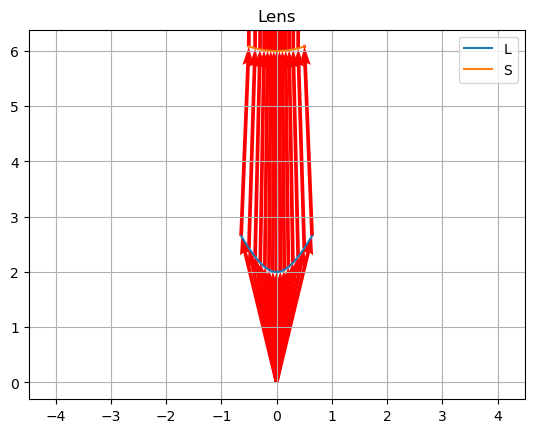

In [92]:
step = 1
up = k
low = 0
xr_vectors = xrho[low:up][::step]
m_vectors  = M_array[low:up][::step]
d_vectors  = d_array[low:up][::step]
w_vectors = w_array[low:up][::step]
f_vectors = F_array[low:up][::step]
plt.figure()
plt.plot((xrho[low:up])[:,0],(xrho[low:up])[:,1], label = 'L')
plt.plot((F_array[low:up])[:,0],(F_array[low:up])[:,1], label = 'S')


for i in np.arange(dinterval[low:up][::step].size):
    plt.quiver(0, 0, xr_vectors[i,0], xr_vectors[i,1], angles='xy', scale_units='xy', scale=1, color='red')
    plt.quiver(xr_vectors[i,0], xr_vectors[i,1], d_vectors[i] * m_vectors[i, 0], d_vectors[i] * m_vectors[i, 1], angles='xy', scale_units='xy', scale=1, color='red')
    plt.quiver(f_vectors[i,0], f_vectors[i,1], w_vectors[i,0], w_vectors[i,1], angles='xy', scale_units='xy', scale=1, color='red')


plt.legend()
plt.title("Lens")
plt.grid(True)
plt.axis('equal')
# plt.gca().set_aspect('equal', adjustable='box')
plt.show()

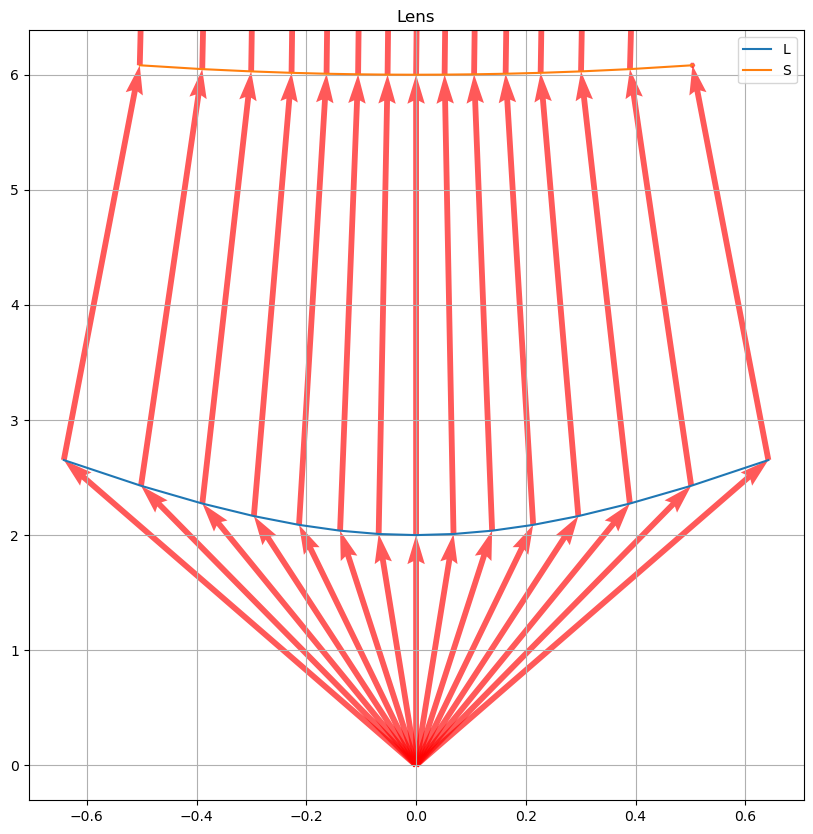

In [93]:
fig, ax = plt.subplots(figsize=(10, 10), dpi=100)
ax.plot((xrho[low:up])[:,0],(xrho[low:up])[:,1], label = 'L')
ax.plot((F_array[low:up])[:,0],(F_array[low:up])[:,1], label = 'S')

for i in np.arange(xr_vectors.shape[0]):
    ax.quiver(0, 0,
              xr_vectors[i, 0], xr_vectors[i, 1],
              angles='xy', scale_units='xy', scale=1, color='red', alpha=0.65)
    ax.quiver(xr_vectors[i, 0], xr_vectors[i, 1],
              d_vectors[i] * m_vectors[i, 0],
              d_vectors[i] * m_vectors[i, 1],
              angles='xy', scale_units='xy', scale=1, color='red', alpha=0.65)
    ax.quiver(f_vectors[i, 0], f_vectors[i, 1],
               w_vectors[i, 0],
               w_vectors[i, 1],
              angles='xy', scale_units='xy', scale=1, color='red', alpha=0.65)

# ax.set_xlim(-0.25, 0.25)    # set your desired x range
# ax.set_ylim(0, 8)    # set your desired y range
# ax.set_aspect('equal', adjustable='box')
# ax.set_xlim(-0.21, 0.21)   # zoom into the lens region
# ax.set_ylim(5.9,6.1)
ax.legend()
ax.set_title('Lens')
ax.grid(True)
plt.show()

In [126]:
from scipy.integrate import quad
from scipy.integrate import quad_vec
from scipy.interpolate import CubicSpline

delta = 0.95/2
k = 15
dinterval = np.linspace(-delta, delta, k)
def findingsolution(dinterval, k_0, n , tol):
    def g(t):
        return t*P(k_0)
    def dg(t):
        return P(k_0)

    def h_t(t, g, dg):
        f = g(t) 
        df = dg(t)
        h_2 = f[2] #z_2'(t)=z_3(t)

        I_r = [t, [f[1]+rho_0, f[2]], [h_2, 0]]
        I_b = [f[0], [g(f[0])[1]+rho_0, g(f[0])[2]], dg(f[0])[1:]] 
        
        h_3 = H_3(I_r, I_b)

        I_r[2][1] = h_3 # z_3'(t)=H_3(t)

        h_1 = H_1(I_r, I_b)
        return np.array([h_1, h_2, h_3])
    
    def H_t(t):
        return h_t(t, g, dg)

    k = dinterval.size
    Z_array = np.zeros((n, k , 3))
    
    for i in np.arange( n):
        status = False
        print(f"i={i}")
        if i == 0:
            for j in np.arange(k):
                Z_array[i][j] = g(dinterval[j])
            continue   

        for j in np.arange(k):
            Z_array[i][j], err, info = quad_vec(H_t, 0, dinterval[j], full_output= True, limit=20, epsabs = tol, epsrel = tol )
            print(f"j={j}, Final error reached: {err}")
             
            if not info.success:
                print(f"Convergence failed! Message: {info.message}")
                status  = info.success
                break
            
        if not info.success:
            break
        
        diff = Z_array[i] - Z_array[i-1]

        # Euclidean norm at each time point, shape (N,)
        norms = np.linalg.norm(diff, axis=1)

        # Worst case over the interval
        max_norm = np.max(norms)      
        if max_norm < tol:
            status = True
            break
        else:
            print(f'norms:{norms}')
            print(f"max_norm = {max_norm}")

        g = CubicSpline(dinterval, Z_array[i])
        dg = g.derivative()
        print("interpolation done")
        def H_t(t):
                return h_t(t, g, dg)  
                      
    return Z_array, i, status 

# arr2, index, status = findingsolution(k_0=k_0,n = 1000, tol = 1e-9)
 

In [129]:
def maximizingdelta(interval ,k_0, n , tol):
    for l in np.arange(n):
        z_array, index, status = findingsolution(dinterval = interval, k_0=k_0,n = 30, tol = tol)
        print(f'l = {l}, delta = {-interval[0]}, status ={status}')
        if status == False:
            interval = interval[1:]
        else:
            break
    return -interval[0]

In [130]:
delta = 0.95/3
k = 500
interval = np.linspace(-delta, 0, k)

maximizingdelta(interval = interval, k_0 = k_0, n = 1000, tol = 1e-9)

i=0
i=1
j=0, Final error reached: 3.9488046343075514
Convergence failed! Message: Target precision not reached.
l = 0, delta = 0.31666666666666665, status =False
i=0
i=1
j=0, Final error reached: 3.3326976948964018
Convergence failed! Message: Target precision not reached.
l = 1, delta = 0.3160320641282565, status =False
i=0
i=1
j=0, Final error reached: 4.087472767423521
Convergence failed! Message: Target precision not reached.
l = 2, delta = 0.31539746158984633, status =False
i=0
i=1
j=0, Final error reached: 6.99143340596301
Convergence failed! Message: Target precision not reached.
l = 3, delta = 0.3147628590514362, status =False
i=0
i=1
j=0, Final error reached: 2.932446313028177
Convergence failed! Message: Target precision not reached.
l = 4, delta = 0.31412825651302606, status =False
i=0
i=1
j=0, Final error reached: 3.00101607268171
Convergence failed! Message: Target precision not reached.
l = 5, delta = 0.31349365397461587, status =False
i=0
i=1
j=0, Final error reached: 3.

np.float64(0.24559118236472943)